<a href="https://colab.research.google.com/github/carolonias-lgtm/Semana-1.1/blob/main/tarefa13_Python_Ciencias_dos_Alimentos_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Integrantes do Grupo:**
- Carolina Ferreira Onias
- Luciana Miki Sumi
- Melissa Rebechi Santana

# 1. Base de dados

A base utilizada neste trabalho é o Perfil de Carboidratos da Tabela
Brasileira de Composição de Alimentos (TBCA), desenvolvida pela
Universidade de São Paulo (USP) e pelo Food Research Center (FoRC).

A planilha utilizada apresenta informações sobre carboidratos disponíveis
e não disponíveis em alimentos. Os valores são expressos em gramas por
100 g de alimento.

Cada linha representa um registro de alimento na base. Os valores de
composição apresentados são, em muitos casos, valores médios ou dados
compilados, e não necessariamente medições individuais de uma mesma
população experimental.

Neste trabalho, a variável "Carboidratos Totais Disponíveis Média (g)"
é utilizada principalmente na análise da distribuição Normal. Para a
comparação de variâncias utilizando a distribuição F, será utilizada a
variável "Umidade Média (g)" presente nas duas abas da base.

É importante não interpretar a possibilidade de ajustar uma curva de
distribuição como evidência de que os dados seguem exatamente aquela
distribuição. As distribuições serão utilizadas como modelos estatísticos
para compreender probabilidades e estatísticas amostrais.

Fonte: Tabela Brasileira de Composição de Alimentos (TBCA), USP/FoRC,
versão 7.0.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats


# Configurações estéticas gerais dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [ ]:
caminho_arquivo = 'Perfil_Carboidratos_TBCA.xlsx'

df_disp = pd.read_excel(caminho_arquivo, sheet_name='Carboidratos Disponíveis', header=2)

print("Aba 'Carboidratos Disponíveis' carregada!")
print(f"Número de registros: {len(df_disp)}")
df_disp.head(3)

Aba 'Carboidratos Disponíveis' carregada!
Número de registros: 109


,Identificação,Nome do Alimento,n,Umidade Média (g),Umidade Desvio,Glicose Média (g),Glicose Desvio,Frutose Média (g),Frutose Desvio,Lactose Média (g),Lactose Desvio,Sacarose Média (g),Sacarose Desvio,Açúcares Totais Disponíveis Média (g),Açúcares Redutores Média (g),Amido Total Média (g),Amido Total Desvio,Amido Disponível Média (g),Carboidratos Totais Disponíveis Média (g),Referências
0,646A,"Arroz, integral, Orysa sativa L., cozido/28 min",1.0,65.75,NaN,0.01,NaN,0.00,NaN,NaN,NaN,0.01,NaN,0.02,NaN,29.92,NaN,29.09,29.11,4
1,645A,"Arroz, polido, Orysa sativa L., cozido/28 min",1.0,75.47,NaN,0.04,NaN,0.01,NaN,NaN,NaN,0.05,NaN,0.10,NaN,20.41,NaN,19.76,19.86,4
2,734A,"Aveia, farelo, Oat bran",1.0,8.66,0.15,0.00,NaN,0.00,NaN,NaN,NaN,0.84,NaN,0.89,NaN,45.29,0.11,42.03,NaN,4


# Distribuição Normal

A distribuição Normal é uma distribuição contínua e simétrica,
caracterizada pelos parâmetros μ (média) e σ (desvio-padrão).

Sua função densidade de probabilidade é:

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}
e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}
$$

em que:

- \(x\) é o valor da variável aleatória;
- $\mu$ é a média da distribuição.
- $\sigma$ é o desvio-padrão, com $\sigma > 0$.

O parâmetro μ determina a posição central da curva. Quando μ aumenta,
a curva se desloca para a direita. O parâmetro σ controla a dispersão:
valores maiores de σ produzem uma curva mais espalhada e mais baixa,
enquanto valores menores produzem uma curva mais concentrada.

Na base utilizada, a distribuição Normal pode ser utilizada como um
modelo para os valores de carboidratos totais disponíveis observados
entre os registros de alimentos.

É importante diferenciar uma observação da base de uma estatística
amostral. Um valor de carboidrato de um alimento é uma observação do
conjunto analisado, enquanto média e desvio-padrão são estatísticas
calculadas a partir de várias observações.

Fonte: SciPy – documentação da distribuição Normal:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

In [ ]:

col_alvo = 'Carboidratos Totais Disponíveis Média (g)'
dados_carb = df_disp[col_alvo].dropna().values

n = len(dados_carb)
media_amostral = np.mean(dados_carb)
desvio_amostral = np.std(dados_carb, ddof=1)
var_amostral = np.var(dados_carb, ddof=1)

print(f"--- Estatísticas Descritivas ---")
print(f"Variável: {col_alvo}")
print(f"Tamanho da amostra (n): {n}")
print(f"Média Amostral (x̄): {media_amostral:.2f} g/100g")
print(f"Desvio Padrão Amostral (s): {desvio_amostral:.2f} g/100g")
print(f"Variância Amostral (s²): {var_amostral:.2f}")

--- Estatísticas Descritivas ---
Variável: Carboidratos Totais Disponíveis Média (g)
Tamanho da amostra (n): 58
Média Amostral (x̄): 26.62 g/100g
Desvio Padrão Amostral (s): 51.13 g/100g
Variância Amostral (s²): 2613.83


<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1948/4134609772.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Distribuição Normal: Efeito dos Parâmetros $\mu$ (Média) e $\sigma$ (Desvio Padrão)')


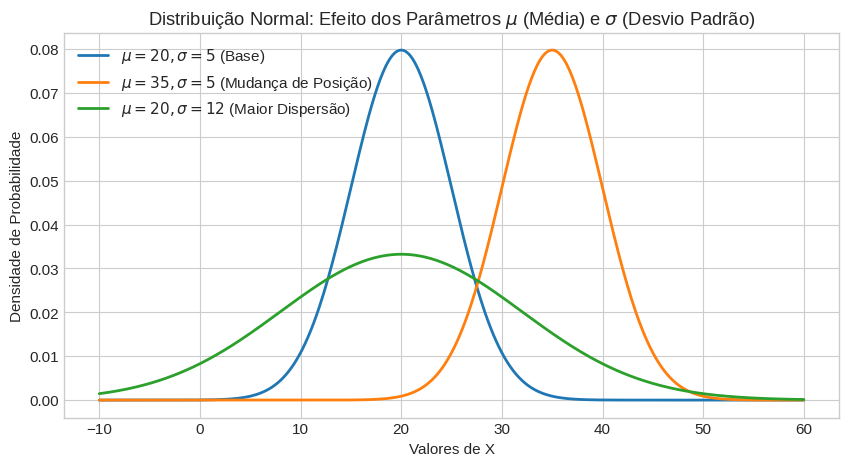

In [ ]:
x_norm = np.linspace(-10, 60, 500)

plt.figure(figsize=(10, 5))
plt.plot(x_norm, stats.norm.pdf(x_norm, loc=20, scale=5), label=r'$\mu=20, \sigma=5$ (Base)', linewidth=2)
plt.plot(x_norm, stats.norm.pdf(x_norm, loc=35, scale=5), label=r'$\mu=35, \sigma=5$ (Mudança de Posição)', linewidth=2)
plt.plot(x_norm, stats.norm.pdf(x_norm, loc=20, scale=12), label=r'$\mu=20, \sigma=12$ (Maior Dispersão)', linewidth=2)

plt.title('Distribuição Normal: Efeito dos Parâmetros $\mu$ (Média) e $\sigma$ (Desvio Padrão)')
plt.xlabel('Valores de X')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()

In [ ]:
x_t = np.linspace(-4, 4, 500)

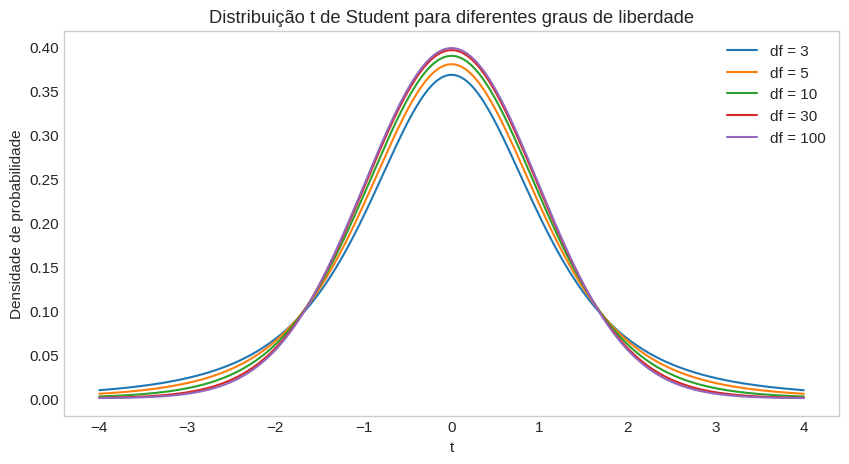

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

x_t = np.linspace(-4, 4, 500)

plt.figure(figsize=(10, 5))

for df in [3, 5, 10, 30, 100]:
    plt.plot(
        x_t,
        t.pdf(x_t, df),
        label=f'df = {df}'
    )

plt.title('Distribuição t de Student para diferentes graus de liberdade')
plt.xlabel('t')
plt.ylabel('Densidade de probabilidade')
plt.legend()
plt.grid()
plt.show()

#Interpretação
- **Efeito dos graus de liberdade:** à medida que os graus de liberdade aumentam, a distribuição t de Student apresenta caudas progressivamente menos pesadas e se aproxima da distribuição Normal. Para valores menores de \(df\), a curva é mais espalhada, indicando maior presença de valores extremos. À medida que \(df\) aumenta, a curva se concentra mais em torno de zero.

# Distribuição Qui-Quadrado

A distribuição qui-quadrado é uma distribuição contínua definida para
valores não negativos. Sua função densidade é:

$$
f(x)=
\frac{1}{2^{\nu/2}\Gamma\left(\frac{\nu}{2}\right)}
x^{\frac{\nu}{2}-1}e^{-x/2}
$$

para $x>0$ e $\nu>0$.

O parâmetro $\nu$ representa os graus de liberdade.

A distribuição qui-quadrado aparece, por exemplo, na análise da
variância de uma amostra. Para uma amostra proveniente de uma população
Normal, a estatística

$$
\chi^2=
\frac{(n-1)s^2}{\sigma_0^2}
$$

segue uma distribuição qui-quadrado com \(n-1\) graus de liberdade.

Nesse contexto, a quantidade modelada é uma estatística construída a
partir da variância amostral, e não uma medição individual de
carboidratos.

Para poucos graus de liberdade, a distribuição é bastante assimétrica.
Com o aumento dos graus de liberdade, ela se torna menos assimétrica.

Fonte: SciPy – documentação da distribuição qui-quadrado:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html

<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1948/3413400450.py:7: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Distribuição Qui-Quadrado ($\chi^2$): Efeito dos Graus de Liberdade ($k$)')
/tmp/ipykernel_1948/3413400450.py:8: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('Estatística $\chi^2$')


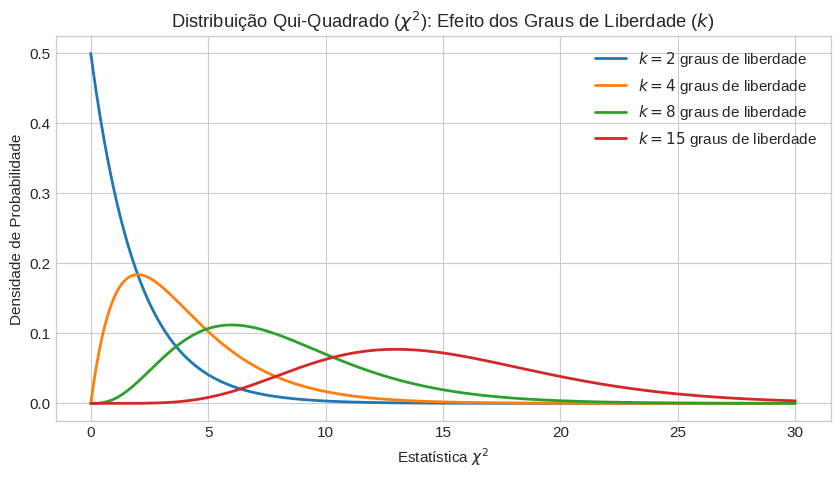

In [ ]:
x_chi = np.linspace(0, 30, 500)

plt.figure(figsize=(10, 5))
for k in [2, 4, 8, 15]:
    plt.plot(x_chi, stats.chi2.pdf(x_chi, df=k), label=f'$k={k}$ graus de liberdade', linewidth=2)

plt.title('Distribuição Qui-Quadrado ($\chi^2$): Efeito dos Graus de Liberdade ($k$)')
plt.xlabel('Estatística $\chi^2$')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()

# Distribuição F de Fisher

A distribuição F é uma distribuição contínua utilizada para representar
a razão entre duas variâncias.

Sua função densidade é:

$$
f(x)=
\frac{
\left(\frac{\nu_1 x}{\nu_2}\right)^{\nu_1/2}
}{
x\,B\left(\frac{\nu_1}{2},\frac{\nu_2}{2}\right)
\left(1+\frac{\nu_1 x}{\nu_2}\right)^{(\nu_1+\nu_2)/2}
}
$$
para \(x>0\).

Os parâmetros são:

- $\nu_1$: graus de liberdade do numerador.
- $\nu_2\$: graus de liberdade do denominador.

A estatística F pode ser representada por:

$$
F=\frac{s_1^2}{s_2^2}
$$

quando as condições necessárias para a aplicação são satisfeitas.

Neste trabalho, a distribuição F será relacionada às variâncias da
umidade dos registros das duas abas da base: "Carboidratos Disponíveis"
e "Carboidratos Não Disponíveis".

Assim, são utilizados dois grupos reais de registros da base, em vez de
graus de liberdade escolhidos arbitrariamente.

Fonte: SciPy – documentação da distribuição F:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html

In [ ]:
caminho_arquivo = '/content/Perfil_Carboidratos_TBCA.xlsx'

In [ ]:
import pandas as pd

caminho_arquivo = '/content/Perfil_Carboidratos_TBCA.xlsx'

df_disp = pd.read_excel(
    caminho_arquivo,
    sheet_name='Carboidratos Disponíveis',
    header=2
)

In [ ]:
df_nao_disp = pd.read_excel(
    caminho_arquivo,
    sheet_name='Carboidratos Não Disponíveis',
    header=2
)

umidade_disp = pd.to_numeric(
    df_disp['Umidade Média (g)'],
    errors='coerce'
).dropna()

umidade_nao_disp = pd.to_numeric(
    df_nao_disp['Umidade Média (g)'],
    errors='coerce'
).dropna()

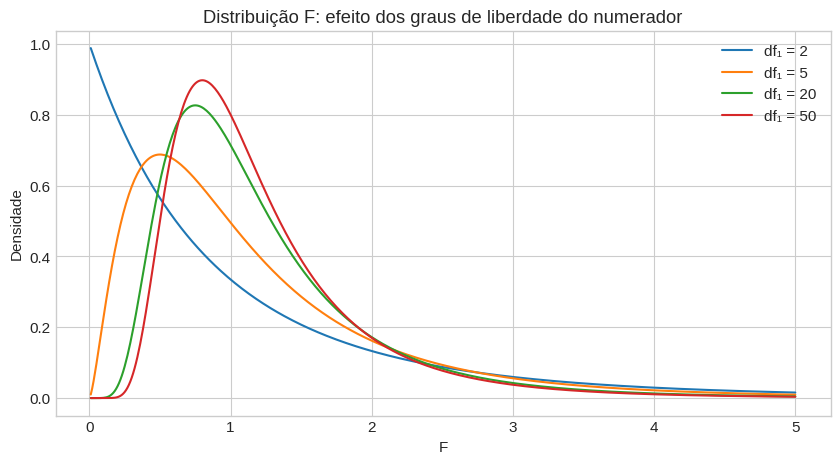

In [ ]:
x_f = np.linspace(0.01, 5, 500)

plt.figure(figsize=(10, 5))

for dfn_val in [2, 5, 20, 50]:
    plt.plot(
        x_f,
        stats.f.pdf(x_f, dfn=dfn_val, dfd=10),
        label=f'df₁ = {dfn_val}'
    )

plt.title('Distribuição F: efeito dos graus de liberdade do numerador')
plt.xlabel('F')
plt.ylabel('Densidade')
plt.legend()
plt.show()

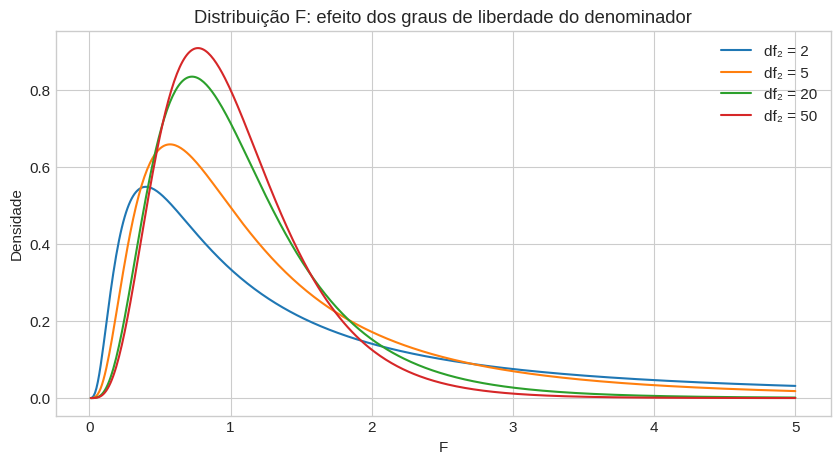

In [ ]:
plt.figure(figsize=(10, 5))

for dfd_val in [2, 5, 20, 50]:
    plt.plot(
        x_f,
        stats.f.pdf(x_f, dfn=10, dfd=dfd_val),
        label=f'df₂ = {dfd_val}'
    )

plt.title('Distribuição F: efeito dos graus de liberdade do denominador')
plt.xlabel('F')
plt.ylabel('Densidade')
plt.legend()
plt.show()

# Interpretação

A distribuição F depende de dois graus de liberdade. O primeiro,
$\nu_1$, está associado à variância do numerador, enquanto o segundo,
$\nu_2$, está associado à variância do denominador.

Ao modificar $\nu_1$ mantendo $\nu_2$ constante, o formato da curva
se altera porque muda a distribuição da variância estimada no numerador.

Ao modificar $\nu_2$ mantendo $\nu_nu_1$ constante, ocorre alteração
na dispersão e na forma da distribuição associada à variância do
denominador.

Assim, os dois graus de liberdade influenciam a forma da distribuição
F de maneira distinta.

## Pergunta contextualizada — Distribuição Normal

Considerando os valores de carboidratos totais disponíveis registrados
na base, qual seria a probabilidade, segundo o modelo Normal ajustado à
média e ao desvio-padrão da amostra, de um registro apresentar:

1. até 10 g de carboidratos por 100 g;
2. entre 10 e 30 g por 100 g;
3. mais de 40 g por 100 g?

Também será calculado o percentil 90.

Esses valores são utilizados como limites de análise do modelo e não
representam limites nutricionais ou recomendações de consumo.

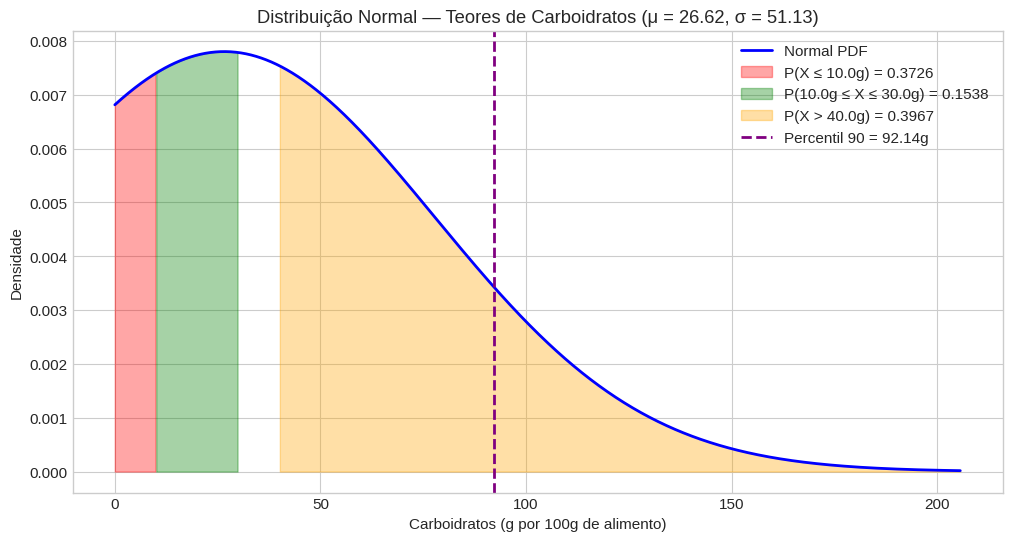

Probabilidade acumulada P(X <= 10.0g): 0.3726
Probabilidade entre 10.0g e 30.0g: 0.1538
Probabilidade acima de 40.0g: 0.3967
Percentil 90: 92.14 g/100g


In [ ]:
mu = media_amostral
sigma = desvio_amostral

# Limites escolhidos para a pergunta contextualizada (em g/100g)
val_inf = 10.0
val_sup = 30.0
val_cauda = 40.0

# Cálculos de probabilidade
p_acumulada = stats.norm.cdf(val_inf, loc=mu, scale=sigma)
p_intervalo = stats.norm.cdf(val_sup, loc=mu, scale=sigma) - stats.norm.cdf(val_inf, loc=mu, scale=sigma)
p_superior = stats.norm.sf(val_cauda, loc=mu, scale=sigma)
p90 = stats.norm.ppf(0.90, loc=mu, scale=sigma)

# Gráfico
x = np.linspace(max(0, mu - 3.5*sigma), mu + 3.5*sigma, 1000)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(12, 6))
plt.plot(x, y, 'b-', linewidth=2, label='Normal PDF')

plt.fill_between(x, 0, y, where=(x <= val_inf), color='red', alpha=0.35, label=f'P(X ≤ {val_inf}g) = {p_acumulada:.4f}')
plt.fill_between(x, 0, y, where=((x >= val_inf) & (x <= val_sup)), color='green', alpha=0.35, label=f'P({val_inf}g ≤ X ≤ {val_sup}g) = {p_intervalo:.4f}')
plt.fill_between(x, 0, y, where=(x >= val_cauda), color='orange', alpha=0.35, label=f'P(X > {val_cauda}g) = {p_superior:.4f}')
plt.axvline(p90, color='purple', linestyle='--', linewidth=2, label=f'Percentil 90 = {p90:.2f}g')

plt.title(f'Distribuição Normal — Teores de Carboidratos (μ = {mu:.2f}, σ = {sigma:.2f})')
plt.xlabel('Carboidratos (g por 100g de alimento)')
plt.ylabel('Densidade')
plt.legend(loc='upper right')
plt.show()

print(f"Probabilidade acumulada P(X <= {val_inf}g): {p_acumulada:.4f}")
print(f"Probabilidade entre {val_inf}g e {val_sup}g: {p_intervalo:.4f}")
print(f"Probabilidade acima de {val_cauda}g: {p_superior:.4f}")
print(f"Percentil 90: {p90:.2f} g/100g")

## Pergunta contextualizada — Distribuição t

Considere a estatística t utilizada para padronizar uma média amostral
em relação a um valor de referência.

Qual é a probabilidade de uma estatística t com os graus de liberdade
da amostra apresentar:

1. valor menor ou igual a -1,96;
2. valor entre -1,96 e 1,96;
3. valor superior a 1,96?

Também será calculado o percentil 95 da distribuição t.

A análise representa a distribuição de uma estatística amostral e não
a distribuição dos teores individuais de carboidratos.

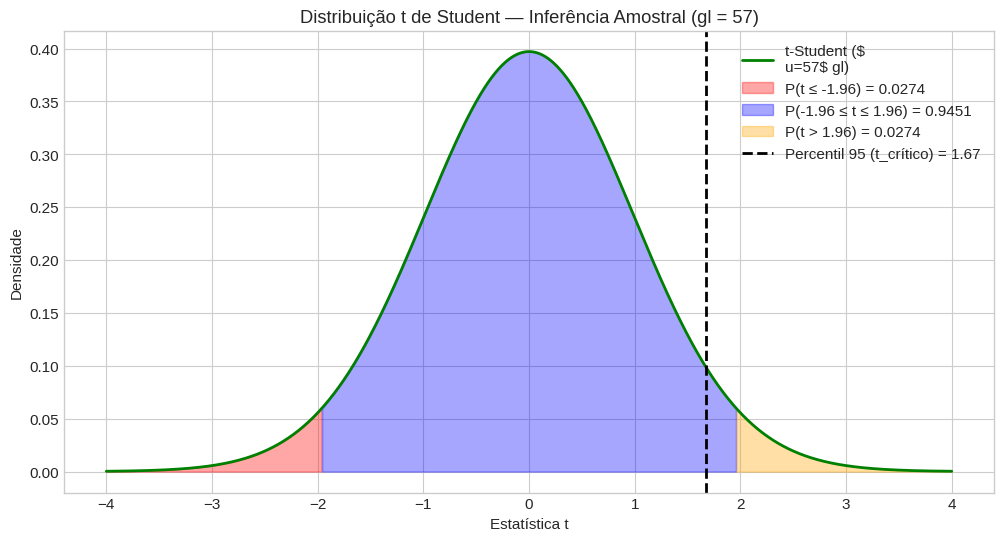

Probabilidade acumulada P(t <= -1.96): 0.0274
Probabilidade no intervalo P(-1.96 <= t <= 1.96): 0.9451
Probabilidade superior P(t > 1.96): 0.0274
Percentil 95 (ponto crítico a 5% de significância): 1.6720


In [ ]:
df_t = n - 1

t_acumulada = stats.t.cdf(-1.96, df=df_t)
t_intervalo = stats.t.cdf(1.96, df=df_t) - stats.t.cdf(-1.96, df=df_t)
t_superior = stats.t.sf(1.96, df=df_t)
t_p95 = stats.t.ppf(0.95, df=df_t)

xt = np.linspace(-4, 4, 1000)
yt = stats.t.pdf(xt, df=df_t)

plt.figure(figsize=(12, 6))
plt.plot(xt, yt, 'g-', linewidth=2, label=f't-Student ($\nu={df_t}$ gl)')

plt.fill_between(xt, 0, yt, where=(xt <= -1.96), color='red', alpha=0.35, label=f'P(t ≤ -1.96) = {t_acumulada:.4f}')
plt.fill_between(xt, 0, yt, where=((xt >= -1.96) & (xt <= 1.96)), color='blue', alpha=0.35, label=f'P(-1.96 ≤ t ≤ 1.96) = {t_intervalo:.4f}')
plt.fill_between(xt, 0, yt, where=(xt >= 1.96), color='orange', alpha=0.35, label=f'P(t > 1.96) = {t_superior:.4f}')
plt.axvline(t_p95, color='black', linestyle='--', linewidth=2, label=f'Percentil 95 (t_crítico) = {t_p95:.2f}')

plt.title(f'Distribuição t de Student — Inferência Amostral (gl = {df_t})')
plt.xlabel('Estatística t')
plt.ylabel('Densidade')
plt.legend()
plt.show()

print(f"Probabilidade acumulada P(t <= -1.96): {t_acumulada:.4f}")
print(f"Probabilidade no intervalo P(-1.96 <= t <= 1.96): {t_intervalo:.4f}")
print(f"Probabilidade superior P(t > 1.96): {t_superior:.4f}")
print(f"Percentil 95 (ponto crítico a 5% de significância): {t_p95:.4f}")

## Pergunta contextualizada — Distribuição Qui-Quadrado

Considerando uma estatística qui-quadrado associada à variância amostral
dos registros de carboidratos disponíveis, qual é a probabilidade de a
estatística apresentar:

1. valor até 80% dos seus graus de liberdade;
2. valor entre 80% e 120% dos seus graus de liberdade;
3. valor acima de 120% dos seus graus de liberdade?

Também será calculado o percentil 95.

Os limites foram definidos em relação aos graus de liberdade para
facilitar a interpretação da distribuição e não representam valores
experimentais observados diretamente na base.

<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1948/4270152697.py:23: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('Valor Qui-Quadrado ($\chi^2$)')


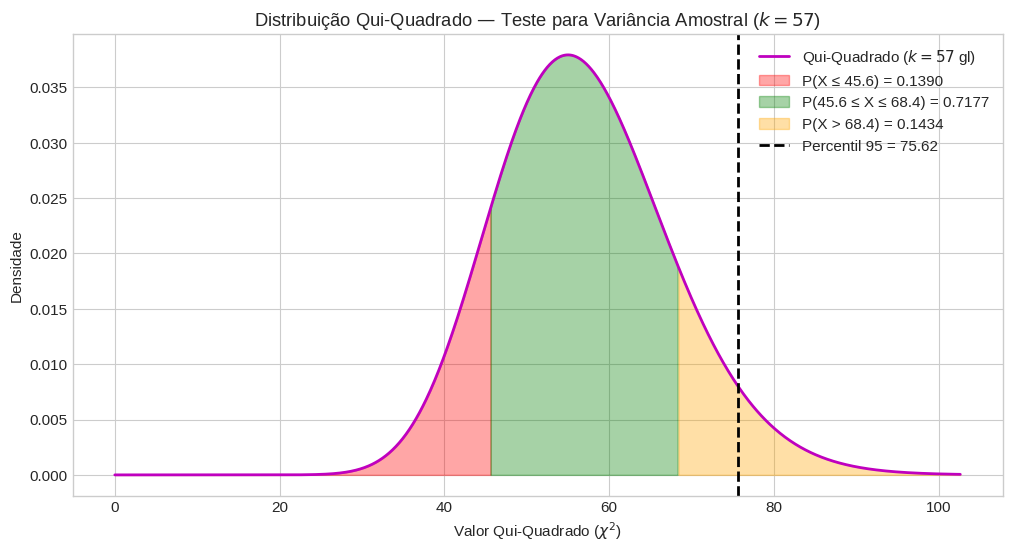

Probabilidade acumulada P(X <= 45.6): 0.1390
Probabilidade entre 45.6 e 68.4: 0.7177
Probabilidade superior P(X > 68.4): 0.1434
Percentil 95: 75.62


In [ ]:
df_chi = n - 1

lim_inf_chi = df_chi * 0.8
lim_sup_chi = df_chi * 1.2

q_acumulada = stats.chi2.cdf(lim_inf_chi, df=df_chi)
q_intervalo = stats.chi2.cdf(lim_sup_chi, df=df_chi) - stats.chi2.cdf(lim_inf_chi, df=df_chi)
q_superior = stats.chi2.sf(lim_sup_chi, df=df_chi)
q_p95 = stats.chi2.ppf(0.95, df=df_chi)

x_chi_val = np.linspace(0, df_chi * 1.8, 1000)
y_chi = stats.chi2.pdf(x_chi_val, df=df_chi)

plt.figure(figsize=(12, 6))
plt.plot(x_chi_val, y_chi, 'm-', linewidth=2, label=f'Qui-Quadrado ($k={df_chi}$ gl)')

plt.fill_between(x_chi_val, 0, y_chi, where=(x_chi_val <= lim_inf_chi), color='red', alpha=0.35, label=f'P(X ≤ {lim_inf_chi:.1f}) = {q_acumulada:.4f}')
plt.fill_between(x_chi_val, 0, y_chi, where=((x_chi_val >= lim_inf_chi) & (x_chi_val <= lim_sup_chi)), color='green', alpha=0.35, label=f'P({lim_inf_chi:.1f} ≤ X ≤ {lim_sup_chi:.1f}) = {q_intervalo:.4f}')
plt.fill_between(x_chi_val, 0, y_chi, where=(x_chi_val >= lim_sup_chi), color='orange', alpha=0.35, label=f'P(X > {lim_sup_chi:.1f}) = {q_superior:.4f}')
plt.axvline(q_p95, color='black', linestyle='--', linewidth=2, label=f'Percentil 95 = {q_p95:.2f}')

plt.title(f'Distribuição Qui-Quadrado — Teste para Variância Amostral ($k = {df_chi}$)')
plt.xlabel('Valor Qui-Quadrado ($\chi^2$)')
plt.ylabel('Densidade')
plt.legend()
plt.show()

print(f"Probabilidade acumulada P(X <= {lim_inf_chi:.1f}): {q_acumulada:.4f}")
print(f"Probabilidade entre {lim_inf_chi:.1f} e {lim_sup_chi:.1f}: {q_intervalo:.4f}")
print(f"Probabilidade superior P(X > {lim_sup_chi:.1f}): {q_superior:.4f}")
print(f"Percentil 95: {q_p95:.2f}")

In [ ]:
print("df_disp existe?", 'df_disp' in globals())
print("df_nao_disp existe?", 'df_nao_disp' in globals())
print("umidade_disp existe?", 'umidade_disp' in globals())
print("umidade_nao_disp existe?", 'umidade_nao_disp' in globals())

df_disp existe? False
df_nao_disp existe? False
umidade_disp existe? False
umidade_nao_disp existe? False


In [ ]:
print("df_disp existe?", 'df_disp' in globals())
...

df_disp existe? True


In [ ]:
# Graus de liberdade dos dois grupos reais

dfn = len(umidade_disp) - 1
dfd = len(umidade_nao_disp) - 1

# Variâncias observadas
var_disp = umidade_disp.var(ddof=1)
var_nao_disp = umidade_nao_disp.var(ddof=1)

# Razão das variâncias
F_observado = var_disp / var_nao_disp

print(f"Variância - carboidratos disponíveis: {var_disp:.2f}")
print(f"Variância - carboidratos não disponíveis: {var_nao_disp:.2f}")
print(f"Graus de liberdade do numerador: {dfn}")
print(f"Graus de liberdade do denominador: {dfd}")
print(f"Razão F observada: {F_observado:.4f}")

Variância - carboidratos disponíveis: 814.21
Variância - carboidratos não disponíveis: 1140.18
Graus de liberdade do numerador: 96
Graus de liberdade do denominador: 133
Razão F observada: 0.7141


In [21]:
from scipy import stats

In [22]:
# Probabilidades da distribuição F

f_acumulada = stats.f.cdf(
    0.6,
    dfn=dfn,
    dfd=dfd
)

f_intervalo = (
    stats.f.cdf(1.8, dfn=dfn, dfd=dfd)
    - stats.f.cdf(0.6, dfn=dfn, dfd=dfd)
)

f_superior = stats.f.sf(
    1.8,
    dfn=dfn,
    dfd=dfd
)

f_p95 = stats.f.ppf(
    0.95,
    dfn=dfn,
    dfd=dfd
)

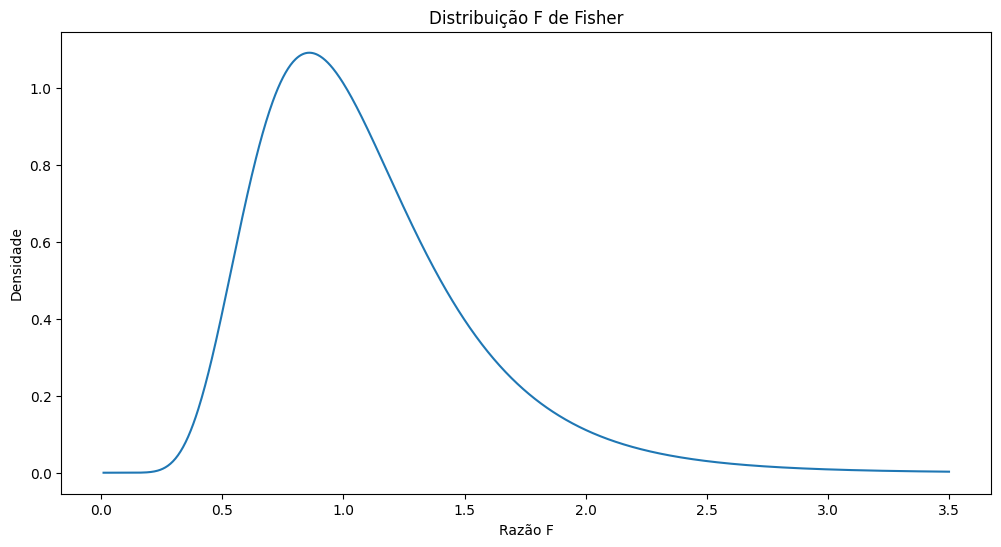

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

dfn = 29
dfd = 24

xf_val = np.linspace(0.01, 3.5, 1000)
yf = stats.f.pdf(xf_val, dfn=dfn, dfd=dfd)

plt.figure(figsize=(12, 6))
plt.plot(xf_val, yf)

plt.xlabel('Razão F')
plt.ylabel('Densidade')
plt.title('Distribuição F de Fisher')

plt.show()

## Pergunta contextualizada — Distribuição F

A variabilidade da umidade é diferente entre os registros classificados
na base como carboidratos disponíveis e os registros classificados como
carboidratos não disponíveis?

Para explorar essa questão, será calculada a razão entre a variância da
umidade dos dois grupos:

$$
F = \frac{s^2_{\text{disponíveis}}}
{s^2_{\text{não disponíveis}}}
$$

A razão observada é comparada com a distribuição F, utilizando os graus
de liberdade dos dois grupos.

A análise deve ser interpretada com cautela, pois os registros da TBCA
não constituem necessariamente amostras aleatórias independentes de
duas populações Normalmente distribuídas. Portanto, a distribuição F
será utilizada como modelo estatístico, e não como prova de que as
condições teóricas do teste são satisfeitas.

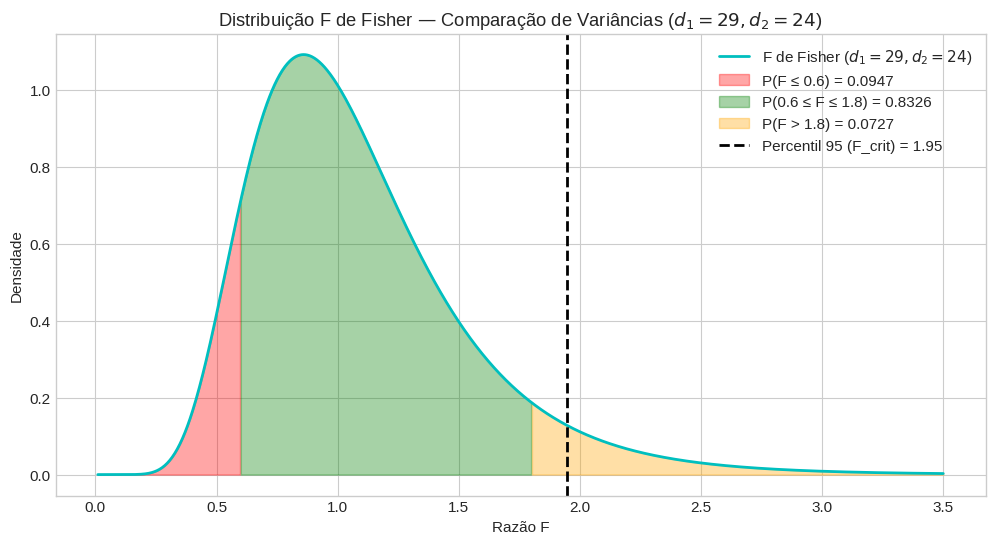

Probabilidade acumulada P(F <= 0.6): 0.0947
Probabilidade entre 0.6 e 1.8: 0.8326
Probabilidade superior P(F > 1.8): 0.0727
Percentil 95 (Valor Crítico a 5%): 1.95


In [ ]:
dfn, dfd = 29, 24  # Graus de liberdade hipotéticos de dois grupos de alimentos

f_acumulada = stats.f.cdf(0.6, dfn=dfn, dfd=dfd)
f_intervalo = stats.f.cdf(1.8, dfn=dfn, dfd=dfd) - stats.f.cdf(0.6, dfn=dfn, dfd=dfd)
f_superior = stats.f.sf(1.8, dfn=dfn, dfd=dfd)
f_p95 = stats.f.ppf(0.95, dfn=dfn, dfd=dfd)

xf_val = np.linspace(0.01, 3.5, 1000)
yf = stats.f.pdf(xf_val, dfn=dfn, dfd=dfd)

plt.figure(figsize=(12, 6))
plt.plot(xf_val, yf, 'c-', linewidth=2, label=f'F de Fisher ($d_1={dfn}, d_2={dfd}$)')

plt.fill_between(xf_val, 0, yf, where=(xf_val <= 0.6), color='red', alpha=0.35, label=f'P(F ≤ 0.6) = {f_acumulada:.4f}')
plt.fill_between(xf_val, 0, yf, where=((xf_val >= 0.6) & (xf_val <= 1.8)), color='green', alpha=0.35, label=f'P(0.6 ≤ F ≤ 1.8) = {f_intervalo:.4f}')
plt.fill_between(xf_val, 0, yf, where=(xf_val >= 1.8), color='orange', alpha=0.35, label=f'P(F > 1.8) = {f_superior:.4f}')
plt.axvline(f_p95, color='black', linestyle='--', linewidth=2, label=f'Percentil 95 (F_crit) = {f_p95:.2f}')

plt.title(f'Distribuição F de Fisher — Comparação de Variâncias ($d_1={dfn}, d_2={dfd}$)')
plt.xlabel('Razão F')
plt.ylabel('Densidade')
plt.legend()
plt.show()

print(f"Probabilidade acumulada P(F <= 0.6): {f_acumulada:.4f}")
print(f"Probabilidade entre 0.6 e 1.8: {f_intervalo:.4f}")
print(f"Probabilidade superior P(F > 1.8): {f_superior:.4f}")
print(f"Percentil 95 (Valor Crítico a 5%): {f_p95:.2f}")

# 7. Referências

- TABELA BRASILEIRA DE COMPOSIÇÃO DE ALIMENTOS (TBCA). Universidade de
São Paulo (USP); Food Research Center (FoRC). Perfil de carboidratos.
Versão 7.0.

- TBCA – Tabela Brasileira de Composição de Alimentos.
https://www.tbca.net.br/

- SCIPY. Statistical functions – Normal distribution.
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

- SCIPY. Statistical functions – Student's t distribution.
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

- SCIPY. Statistical functions – Chi-square distribution.
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html

- SCIPY. Statistical functions – F distribution.
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html